Inference time: 1.9621002674102783 seconds
Inference time: 1.9418385028839111 seconds
Inference time: 1.948516607284546 seconds
Inference time: 1.9381318092346191 seconds
Inference time: 1.9468088150024414 seconds
Inference time: 1.9458909034729004 seconds
Inference time: 1.9451866149902344 seconds
Inference time: 1.951291561126709 seconds
Inference time: 1.9505155086517334 seconds
Inference time: 1.9527769088745117 seconds
Inference time: 1.9572937488555908 seconds
Inference time: 1.953108310699463 seconds
Inference time: 1.9549243450164795 seconds
Inference time: 1.958103895187378 seconds
Inference time: 1.9592523574829102 seconds
Inference time: 1.9577076435089111 seconds
Inference time: 1.9600787162780762 seconds
Inference time: 1.9622886180877686 seconds
Inference time: 1.9645264148712158 seconds
Inference time: 1.9642982482910156 seconds
Inference time: 1.9638280868530273 seconds
Inference time: 1.9615392684936523 seconds
Inference time: 1.9716668128967285 seconds
Inference time:

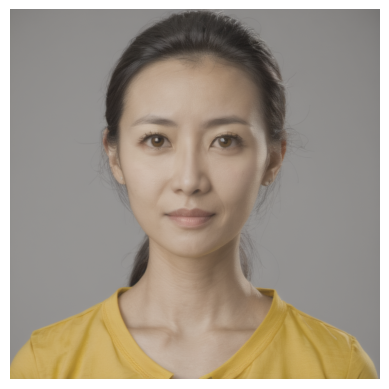

In [1]:
import sys
import tritonclient.grpc as grpcclient
import numpy as np
import time

# Configuration
model_name = "stable_diffusion_xl"
server_url = "localhost:8001"

try:
    triton_client = grpcclient.InferenceServerClient(url=server_url)
except Exception as e:
    print(f"channel creation failed: {str(e)}")
    sys.exit(1)

def generate_image(prompt: str, negative_prompt: str, seed: int):
    # Create input tensors
    inputs = []
    inputs.append(grpcclient.InferInput("prompt", [1, 1], "BYTES"))
    inputs.append(grpcclient.InferInput("negative_prompt", [1, 1], "BYTES"))
    # Add seed parameter to the input tensors
    inputs.append(grpcclient.InferInput("seed", [1, 1], "INT32"))


    # Set input data
    inputs[0].set_data_from_numpy(np.array([[prompt]], dtype=np.object_))
    inputs[1].set_data_from_numpy(np.array([[negative_prompt]], dtype=np.object_))
    inputs[2].set_data_from_numpy(np.array([[seed]], dtype=np.int32))

    # Create output tensor
    outputs = []
    outputs.append(grpcclient.InferRequestedOutput("generated_image"))

    # Send request to Triton server
    start_time = time.time()
    results = triton_client.infer(model_name=model_name, inputs=inputs, outputs=outputs)
    end_time = time.time()

    # Calculate and print the time taken for inference
    print(f"Inference time: {end_time - start_time} seconds")

    # Get the output data
    generated_image = results.as_numpy("generated_image")
    return generated_image

prompts = [
    "Portrait shot of a woman, yellow shirt, photograph",
    "Little girl holding a teddy bear, in the middle of nowhere, photograph",
    "Portrait of an arctic fox in the tundra, light teal and amber, minimalist, photograph",
    "Confused woman, sci - fi, future, blue glow color, orange, hologram, photograph",
    "Symmetrical, macro shot, crying womans face, half of face is organic flowing RGB low poly, depth of field",
    "Beautiful woman future funk psychedelic",
    "Mosaic of a colorful mushroom with intricate patterns, vibrant and detailed, sharp, mosaic background, vector art",
    "Illustration of a man in red hoodie, minimalist, graphic design poster art, dark cyan and sky - blue, honeycore",
    "a bottle of perfume on a clean backdrop, surrounded by fragrant white flowers, product photography, minimalistic, natural light",
    "a bedroom with large windows and modern furniture, gray and gold, luxurious, mid century modern style",
    "an aerial drone shot of the breathtaking landscape of the Bora Bora islands, with sparkling waters under the sun",
    "extreme closeup shot of an old man with a long gray hair and head covered in wrinkles; focused expression looking at camera",
    "Simple flat vector illustration of a woman sitting at the desk with her laptop with a puppy, isolated on white background",
    "Chibi pixel art, game asset for an rpg game on a white background featuring the armor of a dragon sorcerer wielding the power of fire surrounded by a matching item set",
    "a macro wildlife photo of a green frog in a rainforest pond, highly detailed, eye-level shot",
    "kid's coloring book, a happy young girl holding a flower, cartoon, thick lines, black and white, white background",
    "Golden-haired elementary school white boy hugging his black-hair Taiwanese buddy face-to-face on dusk street, unreal engine, greg rutkowski, loish, rhads, beeple, makoto shinkai and lois van baarle, ilya kuvshinov, rossdraws, tom bagshaw, alphonse mucha, global illumination, detailed and intricate environment",
    "Tan skin Anime boy wearing a large black sweater and cat ear beanie with brown hair and eyes, full body, baggy cargo pants, full body, reference",
    "Fawn French Bulldog with big eyes, short legs, and chunky, stocky body eating food",
    "A white goose holding a paint brush",
    "Black, African descent, looks Japanese, wears glasses, Naruto type art, bandage on his nose, male, Anime 2D art, lazy eyes, Japanese earring in one ear, no beard, smiles sinisterly",
    "Male cow fursona wearing a red beanie",
    "a beautiful hyper-realistic anime Lofi, painted by greg rutkowski makoto shinkai takashi takeuchi studio ghibli, akihiko yoshida, anime, clean soft lighting, finely detailed features, high-resolution, perfect art, stunning atmosphere, trending on pixiv fanbox",
    "a woman with a beautiful face is enjoying a summer festival wearing a kimono, long white hair, looks like an older sister with a small body, is holding a traditional Japanese umbrella with a faint smile, her head is facing backwards as if inviting her to play and she is running with her arms behind her, there is also a lock of patterned hair flower",
    "A stunning photograph of a serene mountain lake at sunrise, with crystal-clear reflections and soft pastel skies",
    "A high-resolution image of an ancient oak tree in a lush forest, sunlight filtering through the leaves",
    "An ultra-realistic photograph of the Milky Way galaxy seen from a remote desert, under clear skies",
    "A detailed image of a colorful street market in Marrakech at golden hour, with vibrant fabrics and bustling crowds",
    "A professional photograph of a majestic bald eagle in flight, with a crisp focus on its sharp eyes and detailed feathers",
    "A perfect image of a charming cobblestone street in Prague, with historical buildings and a peaceful early morning atmosphere",
    "A photo-realistic image of a modern city skyline at night, with shimmering lights and reflections on a river",
    "An authentic-looking photograph of the Northern Lights over a snowy Lapland landscape, with vivid colors and clear stars",
    "A high-quality image of a vintage 1950s diner, with classic cars parked outside and a sunset backdrop",
    "An elegant photograph of a grand ballroom from the Victorian era, with ornate decorations and a grand chandelier",
    "A striking photograph of a powerful thunderstorm over the ocean, with dramatic lightning strikes and rolling waves",
    "An image of a peaceful Zen garden with smooth stones, raked sand, and a calming waterfall",
    "A high-resolution photograph of a seasoned fisherman at dawn, casting a net into the sea, with the golden light reflecting off the water",
    "A professional close-up shot of a woman's face, half-illuminated by the sunset, showcasing a detailed texture of her skin and a contemplative expression",
    "An image capturing a street dancer in mid-air during a dynamic breakdance move, with urban graffiti in the background",
    "A vibrant photograph of a group of people dressed in traditional attire at a cultural festival, dancing in a blur of colors and fabrics",
    "A cinematic-style photograph of a lone astronaut in a spacesuit, standing on a rocky alien landscape with Earth visible in the sky above",
    "Capture the quiet intensity in the eyes of a chess grandmaster poised over the board in a high-stakes match",
    "Close-up: A young girl's freckled face, focused and thoughtful, as she reads a book under the shade of an old tree",
    "Underwater photography of a diver among swirling schools of fish, light filtering down from above",
    "Evening falls on a city street musician, his guitar casting long shadows as he strums for the passing crowd",
    "High above the city, a construction worker perches on a steel beam, with a backdrop of the skyline stretching into the distance",
    "Document the intense expression of a potter as they shape a clay vessel, hands and wheel both a blur of motion",
    "A street portrait captures the weathered face of a long-time vendor, his cart a staple in the neighborhood for generations",
    "During golden hour, a group of children race through a field, their silhouettes a dance of joy against the setting sun",
    "Zoomed-in shot capturing the intense focus of a violinist as the bow gracefully sweeps across the strings, emotions etched into their performance",
]

seed = 42

# prompts = [
    # "sailing ship in storm by Leonardo da Vinci"
# ]

negative_prompts = "out of frame, nude, duplicate, watermark, signature, mutated, text, blurry, worst quality, low quality, artificial, texture artifacts, jpeg artifacts"

import concurrent.futures

def generate_images_in_parallel(prompts, negative_prompt):
    with concurrent.futures.ThreadPoolExecutor() as executor:
        images = []
        start_time = time.time()

        future_to_prompt = {executor.submit(generate_image, prompt, negative_prompt, seed): prompt for prompt in prompts}
        for future in concurrent.futures.as_completed(future_to_prompt):
            prompt = future_to_prompt[future]
            try:
                generated_image = future.result()
                images.append(generated_image)

                print(f"Generated image for prompt: {prompt}")
                # You can add code here to handle the generated image, e.g., save it or display it
            except Exception as exc:
                print(f"Prompt {prompt} generated an exception: {exc}")
        
        end_time = time.time()
        print(f"Total time taken: {end_time - start_time} seconds")

        return images
    
def generate_images_in_serial(prompts, negative_prompt):
    images = []
    for prompt in prompts:
        images.append(generate_image(prompt, negative_prompt, seed))
    return images

images = generate_images_in_serial(prompts, negative_prompts)

import matplotlib.pyplot as plt

plt.imshow(images[0][0])
plt.axis('off')
plt.show()

In [28]:
import PIL
import os

# Create folder tests if needed
if not os.path.exists("tests"):
    os.makedirs("tests")

# Save all images named index.jpg
for i, image in enumerate(images):
    PIL.Image.fromarray(image[0]).save(f"tests/{i}-test.jpg")